# 台北市衛星影像搜尋：NDVI,NDBI,LST

### 第一步：設定環境參數與台北市區搜尋範圍
此區塊將設定 Planetary Computer API 連線資訊、時間範圍 (2025年夏季)、雲量限制，以及覆蓋大同、萬華、中山、中正、大安區的經緯度範圍 (Bounding Box)。
波段需求說明：
* **B04 (Red) + B08 (NIR)**：用於計算 NDVI
* **B08 (NIR) + B11 (SWIR)**：用於計算 NDBI

In [ ]:
# 1. 安裝必要套件
!pip install -q pystac-client planetary-computer rioxarray matplotlib

import os
import time
import warnings
import pystac_client
import planetary_computer as pc
import rioxarray as rxr
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

print("📥 正在初始化繪圖環境與中文字型...")

# ==========================================
# 1. 屏蔽繪圖相關的擾人警告
# ==========================================
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas.plotting")

# ==========================================
# 2. 下載並設定 Noto Sans CJK TC (思源黑體)
# ==========================================
font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    print("   - 尚未找到字型，正在從 Google Fonts 下載...")
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
    print("   - 字型下載完成！")

# 註冊字型到 Matplotlib 的環境中
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False # 確保座標軸的負號正常顯示

print("✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。")

#掛載 Google Drive、設定輸出位置
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/Satellite_output"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 已建立輸出資料夾: {OUTPUT_DIR}")

# ==========================================
# [S1] 環境參數與 API 設定 (整合版)
# ==========================================
STAC_ENDPOINT = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION = "sentinel-2-l2a"
COLLECTION_LST = "landsat-c2-l2"

# 台北市夏季容易有午後雷陣雨，雲量上限設為 30
CLOUD_LIMIT = 30

# 台北核心五區 (大同, 萬華, 中山, 中正, 大安) 的經緯度 Bounding Box
TAIPEI_BBOX_STR = "121.48,25.01,121.56,25.09"
TAIPEI_BBOX = [float(x) for x in TAIPEI_BBOX_STR.split(",")]
# 目標行政區
target_towns = ['大同區', '萬華區', '中山區', '中正區', '大安區', '松山區']

# 目標座標系統 (WGS84 UTM zone 51N) - 後續計算與投影轉換時會用到
TARGET_EPSG = 32651

# 搜尋時間：2025年夏季
EVENT_START = "2025-06-01"
EVENT_END = "2025-08-31"

# NDVI 與 NDBI 所需波段，加上 B02, B03 方便組合 RGB 預覽圖
BANDS = ["B02", "B03", "B04", "B08", "B11"]

📥 正在初始化繪圖環境與中文字型...
   - 尚未找到字型，正在從 Google Fonts 下載...
   - 字型下載完成！
✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。


### 第二步：介接 STAC API 搜尋影像並進行視覺化預覽
連線至微軟 STAC Catalog 進行搜尋。系統會自動篩選出時間區間內「雲量最少」的一張衛星影像，並直接繪製 RGB 預覽圖確認覆蓋狀況。

In [ ]:
# ==========================================
# [S2] 系統設定與 STAC 連線
# ==========================================
# 強制靜音警告並設定字體，確保畫圖專業度
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=FutureWarning)

print("🔗 連線至 Planetary Computer STAC Catalog...")
catalog = pystac_client.Client.open(
    STAC_ENDPOINT,
    modifier=pc.sign_inplace,
)

# 關鍵函數：Robust Search (重試機制與客戶端雲量過濾)
def robust_search(bbox, datetime_range, collection, cloud_max=30, max_items=60, tries=3):
    for attempt in range(tries):
        try:
            search = catalog.search(
                collections=[collection], # 這裡改用上方定義好的 COLLECTION 變數
                bbox=bbox,
                datetime=datetime_range,
                max_items=max_items,
            )
            items = list(search.items())

            # 客戶端雲量過濾
            items = [i for i in items if i.properties.get("eo:cloud_cover", 100) < cloud_max]

            # 依雲量排序，把最乾淨的放前面
            items.sort(key=lambda i: i.properties["eo:cloud_cover"])
            return items

        except Exception as e:
            print(f"⚠️ STAC 搜尋嘗試 {attempt+1} 失敗，正在重試...")
            time.sleep(2 ** attempt)

    raise RuntimeError("STAC search failed 3x")

print(f"✅ 環境初始化完成！台北市搜尋範圍：{TAIPEI_BBOX}")
print(f"✅ 預計擷取波段: {BANDS}")

🔗 連線至 Planetary Computer STAC Catalog...
✅ 環境初始化完成！台北市搜尋範圍：[121.48, 25.01, 121.56, 25.09]
✅ 預計擷取波段: ['B02', 'B03', 'B04', 'B08', 'B11']



🔍 正在搜尋 2025-06-01/2025-08-31 期間的影像 (雲量 < 30%)...
✅ 共找到 6 張符合條件的影像。


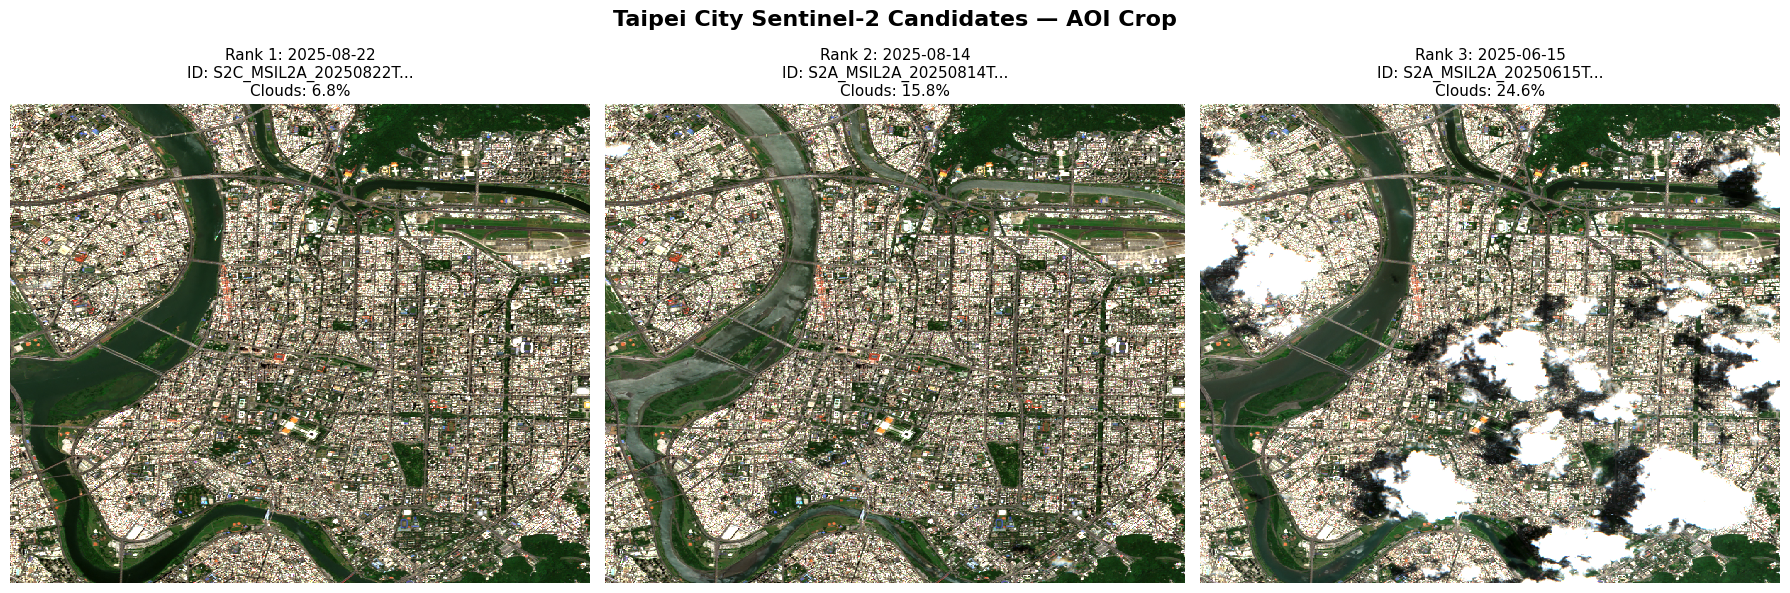

📌 推薦使用 Rank 1 (最乾淨影像): S2C_MSIL2A_20250822T022611_R046_T51RUH_20250822T055915


In [ ]:
# ==========================================
# [S3] 搜尋夏季影像與 Quick-QA 預覽
# ==========================================
search_window = f"{EVENT_START}/{EVENT_END}"
print(f"\n🔍 正在搜尋 {search_window} 期間的影像 (雲量 < {CLOUD_LIMIT}%)...")

# 執行搜尋 (注意這裡加入了 COLLECTION 參數)
items_taipei = robust_search(TAIPEI_BBOX, search_window, COLLECTION, cloud_max=CLOUD_LIMIT)
print(f"✅ 共找到 {len(items_taipei)} 張符合條件的影像。")

if len(items_taipei) == 0:
    print("⚠️ 找不到任何影像，請嘗試放寬 CLOUD_LIMIT 或日期範圍！")
else:
    # 進行 TCI Quick-QA (最多顯示 3 張)
    n = min(len(items_taipei), 3)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
    if n == 1: axes = [axes]

    for i in range(n):
        item = items_taipei[i]
        cloud_pct = item.properties.get("eo:cloud_cover", 0)
        obs_date = item.datetime.strftime("%Y-%m-%d")

        # 串流視覺影像 (TCI) 並使用 overview_level 加快讀取速度
        tci_href = item.assets["visual"].href
        tci = rxr.open_rasterio(tci_href)

        # 進行 BBox 裁切 (rioxarray 的 clip_box 會自動處理 CRS 轉換問題)
        tci_clipped = tci.rio.clip_box(*TAIPEI_BBOX, crs="EPSG:4326")

        # 繪圖
        tci_clipped.plot.imshow(ax=axes[i])
        axes[i].set_title(f"Rank {i+1}: {obs_date}\nID: {item.id[:20]}...\nClouds: {cloud_pct:.1f}%", fontsize=11)
        axes[i].axis('off')

    plt.suptitle(f"Taipei City Sentinel-2 Candidates — AOI Crop", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # 提示使用者紀錄 ID
    best_item = items_taipei[0]
    print(f"📌 推薦使用 Rank 1 (最乾淨影像): {best_item.id}")

### 第三步：計算 NDVI (植被指標) 與 NDBI (建築物指標)

此區塊將載入 Sentinel-2 的特定波段，精確裁切出台北市區範圍，並計算兩項關鍵指標：
1. **NDVI (Normalized Difference Vegetation Index)**：透過近紅外光 (B08) 與紅光 (B04) 計算。數值越高代表植被越茂密。
   $$\text{NDVI}=\frac{\text{NIR}-\text{Red}}{\text{NIR}+\text{Red}}$$
2. **NDBI (Normalized Difference Built-up Index)**：透過短波紅外光 (B11) 與近紅外光 (B08) 計算。數值越高代表建築物/非透水層越密集。
   $$\text{NDBI}=\frac{\text{SWIR}-\text{NIR}}{\text{SWIR}+\text{NIR}}$$

*技術提示：因為 B04/B08 是 10m 解析度，而 B11 是 20m 解析度，程式會在讀取時自動將 B11 重取樣 (Resampling) 至 10m 以對齊矩陣進行計算。*

📥 正在下載並讀取高解析度波段 (這可能需要一點時間)...
🔄 正在對齊解析度 (將 20m 的 SWIR 重新取樣對齊 10m 的 NIR)...
🧮 正在計算指標矩陣...
🎨 正在繪製結果...


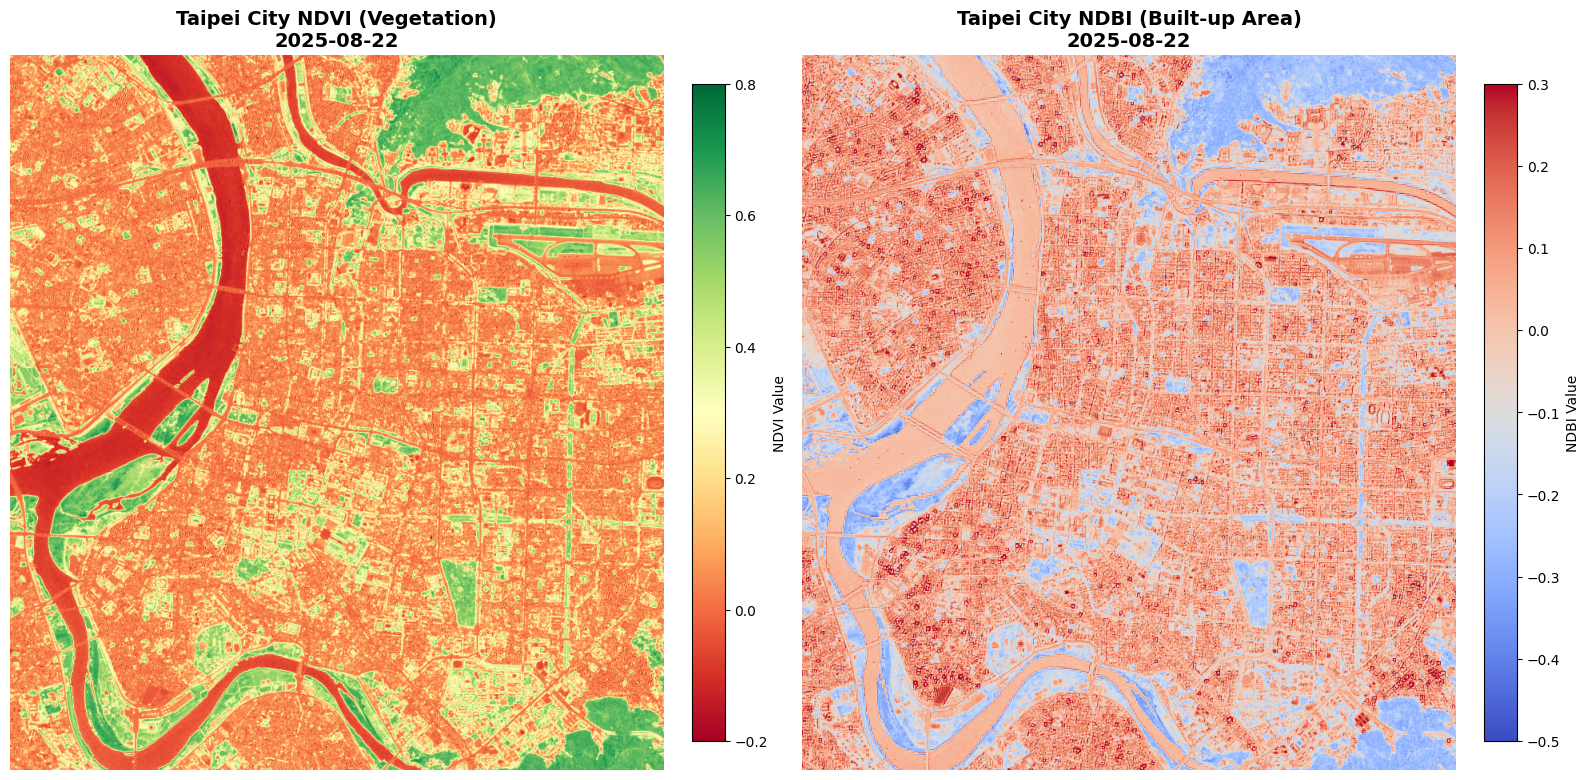

✅ 計算與繪製完成！
💡 觀察指南：
- NDVI (左圖)：深綠色區塊通常是山區或大安森林公園等大型綠地，紅色/黃色則是水體或密集建地。
- NDBI (右圖)：深紅色區塊代表高密度的水泥建築或不透水層，藍色通常是水體或茂密植被。


In [ ]:
# ==========================================
# [S4] 下載波段並計算 NDVI 與 NDBI
# ==========================================
print("📥 正在下載並讀取高解析度波段 (這可能需要一點時間)...")

# 1. 取得波段的 URL
red_href = best_item.assets["B04"].href  # 紅光 (10m)
nir_href = best_item.assets["B08"].href  # 近紅外光 (10m)
swir_href = best_item.assets["B11"].href # 短波紅外光 (20m)

# 2. 開啟波段並直接裁切至台北市範圍
# 這裡沒有使用 overview_level，所以會讀取真實高解析度！
red = rxr.open_rasterio(red_href).rio.clip_box(*TAIPEI_BBOX, crs="EPSG:4326")
nir = rxr.open_rasterio(nir_href).rio.clip_box(*TAIPEI_BBOX, crs="EPSG:4326")
swir = rxr.open_rasterio(swir_href).rio.clip_box(*TAIPEI_BBOX, crs="EPSG:4326")

print("🔄 正在對齊解析度 (將 20m 的 SWIR 重新取樣對齊 10m 的 NIR)...")
# 3. 解析度對齊 (核心關鍵！)
swir_aligned = swir.rio.reproject_match(nir)

print("🧮 正在計算指標矩陣...")
# 4. 轉換為浮點數以避免整數除法錯誤
red_f = red.astype(float)
nir_f = nir.astype(float)
swir_f = swir_aligned.astype(float)

# 5. 執行數學計算
# NDVI = (NIR - Red) / (NIR + Red)
ndvi = (nir_f - red_f) / (nir_f + red_f)

# NDBI = (SWIR - NIR) / (SWIR + NIR)
ndbi = (swir_f - nir_f) / (swir_f + nir_f)

# 清除異常值 (避免出現除以零的無限大或空值，全部補 0)
ndvi = ndvi.where(ndvi.notnull(), 0)
ndbi = ndbi.where(ndbi.notnull(), 0)

print("🎨 正在繪製結果...")
# ==========================================
# [S5] 繪製對比圖
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 繪製 NDVI (使用綠色系，越綠代表植被越密)
# 參數 vmin/vmax 用來固定顏色級距，讓對比更明顯
im1 = axes[0].imshow(ndvi[0], cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[0].set_title(f"Taipei City NDVI (Vegetation)\n{best_item.datetime.strftime('%Y-%m-%d')}", fontsize=14, fontweight='bold')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, label="NDVI Value")

# 繪製 NDBI (使用冷暖色系，越紅代表水泥/建築越密)
im2 = axes[1].imshow(ndbi[0], cmap='coolwarm', vmin=-0.5, vmax=0.3)
axes[1].set_title(f"Taipei City NDBI (Built-up Area)\n{best_item.datetime.strftime('%Y-%m-%d')}", fontsize=14, fontweight='bold')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, label="NDBI Value")

plt.tight_layout()
plt.show()
print("✅ 計算與繪製完成！")
print("💡 觀察指南：")
print("- NDVI (左圖)：深綠色區塊通常是山區或大安森林公園等大型綠地，紅色/黃色則是水體或密集建地。")
print("- NDBI (右圖)：深紅色區塊代表高密度的水泥建築或不透水層，藍色通常是水體或茂密植被。")

### 第四步：資料匯出與儲存 (GeoTIFF)

為了後續「環境熱與生態脆弱度」的 PCA 主成分分析，本區塊將計算完的指標進行儲存：
1. **單一指標輸出**：將 NDVI 與 NDBI 分別存為標準的 GeoTIFF 檔案，保留空間投影資訊 (CRS) 與 10m 解析度。
2. **多波段堆疊 (Stacking)**：(選用) 將多個指標堆疊成單一 TIFF 檔 (Band 1: NDVI, Band 2: NDBI)。這種格式對於後續在 Python (如 `scikit-learn`) 中進行像素級 PCA，或是套用機器學習演算法非常方便。

*注意：為避免碎形多邊形導致系統崩潰，不建議將連續網格直接轉換為向量多邊形 (Polygon)。後續若需結合人口密度等社會經濟資料，建議使用「區域統計 (Zonal Statistics)」，以行政區 (如：里) 為單位擷取網格平均值後，再存為 GPKG 格式。*

In [ ]:
import xarray as xr
import os

# ==========================================
# [S6] 匯出 GeoTIFF 檔案
# ==========================================
print("💾 準備匯出 GeoTIFF 檔案...")

# 1. 儲存單一指標的 TIFF 檔
# rioxarray 的 to_raster 函數會完美保留座標系統 (CRS) 與空間轉換矩陣
ndvi_path = os.path.join(OUTPUT_DIR, "Taipei_NDVI_2025_10m.tif")
ndbi_path = os.path.join(OUTPUT_DIR, "Taipei_NDBI_2025_10m.tif")

# squeeze() 是為了去除多餘的維度 (如 time 或 band=1)，確保匯出為標準的單波段 2D 影像
ndvi.squeeze().rio.to_raster(ndvi_path)
ndbi.squeeze().rio.to_raster(ndbi_path)

print(f"✅ NDVI 已儲存至: {ndvi_path}")
print(f"✅ NDBI 已儲存至: {ndbi_path}")


# 2. (進階) 將 NDVI 與 NDBI 堆疊成單一多波段 GeoTIFF
# 這是為了未來 PCA 分析 (Pixel-based) 做準備
print("\n🥞 正在堆疊多波段影像 (Stacking)...")

# 使用 xarray 將兩個 DataArray 沿著 band 維度結合
stacked_index = xr.concat([ndvi.squeeze(), ndbi.squeeze()], dim="band")
# 重新標註 band 的編號 (1 和 2)
stacked_index = stacked_index.assign_coords(band=[1, 2])
# 將變數名稱更新為更具意義的名稱
stacked_index.name = "Vulnerability_Indices"

stacked_path = os.path.join(OUTPUT_DIR, "Taipei_Stacked_NDVI_NDBI.tif")
stacked_index.rio.to_raster(stacked_path)

print(f"✅ 多波段影像已儲存至: {stacked_path}")
print("   - Band 1: NDVI (綠覆狀況)")
print("   - Band 2: NDBI (不透水層/建築指數)")

print("\n🎉 影像儲存完畢！您可以從 Colab 左側的檔案瀏覽器下載這些 .tif 檔案。")
print("💡 下一步建議：您可以準備台北市「里界」的 Shapefile，使用 `rasterstats` 套件進行 Zonal Statistics，將這些 TIFF 的平均值萃取到各個里之中，再結合人口與空污資料存成 GPKG。")

💾 準備匯出 GeoTIFF 檔案...
✅ NDVI 已儲存至: /content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDVI_2025_10m.tif
✅ NDBI 已儲存至: /content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDBI_2025_10m.tif

🥞 正在堆疊多波段影像 (Stacking)...
✅ 多波段影像已儲存至: /content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Stacked_NDVI_NDBI.tif
   - Band 1: NDVI (綠覆狀況)
   - Band 2: NDBI (不透水層/建築指數)

🎉 影像儲存完畢！您可以從 Colab 左側的檔案瀏覽器下載這些 .tif 檔案。
💡 下一步建議：您可以準備台北市「里界」的 Shapefile，使用 `rasterstats` 套件進行 Zonal Statistics，將這些 TIFF 的平均值萃取到各個里之中，再結合人口與空污資料存成 GPKG。


### 第五步：村里尺度空間篩選與 Zonal Statistics (區域統計)

此區塊將執行以下核心資料處理：
1. **空間篩選**：讀取全台村里 Shapefile，並過濾出台北市的目標五區（松山、大同、萬華、中山、中正、大安）。
2. **CRS 對齊**：將村里的座標系統投影至與衛星影像相同的 `EPSG:32651` (UTM 51N)，確保疊圖精準。
3. **區域統計**：計算每個村里多邊形內 NDVI 與 NDBI 的平均值。
4. **屬性合併**：讀取人口統計 CSV 檔，透過「區名+里名」的鍵值整併資料。
5. **資料正規化**：將環境指標進行 Min-Max 正規化 ($0 \sim 1$)，最後將成果存為 `.gpkg` 格式。

In [ ]:
# 安裝必要的空間運算套件
!pip install -q geopandas rasterstats mapclassify

import os
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats
import numpy as np

# ==========================================
# 1. 設定檔案路徑
# ==========================================
shp_path = "/content/drive/MyDrive/GIS_data/全台村里界shp/VILLAGE_NLSC_121_1150306.shp"
pop_stat_path = "/content/drive/MyDrive/GIS_data/114年12月行政區人口統計_村里_臺北市.csv"
pop_idx_path = "/content/drive/MyDrive/GIS_data/114年12月行政區人口指標_村里_臺北市.csv"

# 先前生成的 TIFF 路徑 (請確認名稱與您存檔的一致)
ndvi_tif = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDVI_2025_10m.tif"
ndbi_tif = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDBI_2025_10m.tif"


# ==========================================
# 2. 空間資料處理與區域統計 (Zonal Stats)
# ==========================================
print("🗺️ 正在讀取並篩選村里圖資...")
# 讀取 SHP
gdf = gpd.read_file(shp_path)

# 統一「臺」與「台」的用字，避免篩選失敗
gdf['COUNTYNAME'] = gdf['COUNTYNAME'].str.replace('台北市', '臺北市')
gdf['TOWNNAME'] = gdf['TOWNNAME'].str.replace('台', '臺')

# 篩選台北市 & 目標五區
gdf_taipei = gdf[(gdf['COUNTYNAME'] == '臺北市') & (gdf['TOWNNAME'].isin(target_towns))].copy()

# 關鍵：將 Vector 的座標系統轉換為與 Raster 一致 (EPSG:32651)
gdf_taipei = gdf_taipei.to_crs(epsg=32651)
print(f"✅ 篩選完成，共計 {len(gdf_taipei)} 個村里。")

# 計算 Zonal Statistics (萃取 mean 平均值)
print("📊 正在計算 NDVI 區域平均值...")
ndvi_stats = zonal_stats(gdf_taipei, ndvi_tif, stats="mean", nodata=0.0)
gdf_taipei['NDVI_mean'] = [stat['mean'] if stat['mean'] is not None else np.nan for stat in ndvi_stats]

print("📊 正在計算 NDBI 區域平均值...")
ndbi_stats = zonal_stats(gdf_taipei, ndbi_tif, stats="mean", nodata=0.0)
gdf_taipei['NDBI_mean'] = [stat['mean'] if stat['mean'] is not None else np.nan for stat in ndbi_stats]

# ==========================================
# 3. 讀取並整併人口 CSV 資料
# ==========================================
print("📄 正在讀取並合併人口統計 CSV...")
try:
    # 台灣政府開放資料通常使用 utf-8 或 big5
    df_pop = pd.read_csv(pop_stat_path, encoding='utf-8')
    df_idx = pd.read_csv(pop_idx_path, encoding='utf-8')
except UnicodeDecodeError:
    df_pop = pd.read_csv(pop_stat_path, encoding='big5')
    df_idx = pd.read_csv(pop_idx_path, encoding='big5')

# 防呆處理：統一清理「臺/台」與空白，建立共用的合併鍵值 (區名 + 里名)
gdf_taipei['Merge_Key'] = gdf_taipei['TOWNNAME'] + gdf_taipei['VILLNAME']

# 假設 CSV 內有 '區域別' (如:臺北市大安區) 或 '鄉鎮市區', 以及 '村里名稱' 等欄位
# 這裡提供一個通用的文字清理建立 Key 的方式 (請依據您實際 CSV 的欄位名稱微調)
# 若您的 CSV 欄位名稱不同，請將下方 '鄉鎮市區', '村里' 替換為實際欄位名
try:
    # 嘗試尋找對應的區、里欄位 (以政府開放資料常見欄位為例)
    town_col = [c for c in df_pop.columns if '區' in c or 'town' in c.lower()][0]
    vill_col = [c for c in df_pop.columns if '里' in c or 'vill' in c.lower()][0]

    df_pop['Merge_Key'] = df_pop[town_col].str.replace('臺北市', '').str.replace('台北市', '') + df_pop[vill_col]
    df_idx['Merge_Key'] = df_idx[town_col].str.replace('臺北市', '').str.replace('台北市', '') + df_idx[vill_col]

    # 進行 Merge (合併)
    gdf_final = gdf_taipei.merge(df_pop, on='Merge_Key', how='left')
    gdf_final = gdf_final.merge(df_idx.drop(columns=[town_col, vill_col], errors='ignore'), on='Merge_Key', how='left')
    print("✅ CSV 資料整併成功！")
except Exception as e:
    print(f"⚠️ CSV 合併發生問題 (可能是欄位名稱對不上): {e}")
    print(f"目前 CSV 欄位有: {df_pop.columns.tolist()}")
    gdf_final = gdf_taipei # 若失敗則先保留地理與指標資料

# ==========================================
# 4. 資料正規化 (Min-Max Normalization)
# ==========================================
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

gdf_final['NDVI_norm'] = min_max_normalize(gdf_final['NDVI_mean'])
gdf_final['NDBI_norm'] = min_max_normalize(gdf_final['NDBI_mean'])

# ==========================================
# 5. 匯出 GPKG
# ==========================================
out_gpkg = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.gpkg"
# 存檔前刪除 dict/list 類型的欄位避免 geopandas 存檔報錯
for col in gdf_final.columns:
    if isinstance(gdf_final[col].iloc[0], (dict, list)):
        gdf_final = gdf_final.drop(columns=[col])

gdf_final.to_file(out_gpkg, driver="GPKG")
print(f"\n🎉 處理完成！整合檔已儲存於: {out_gpkg}")

🗺️ 正在讀取並篩選村里圖資...
✅ 篩選完成，共計 220 個村里。
📊 正在計算 NDVI 區域平均值...
📊 正在計算 NDBI 區域平均值...
📄 正在讀取並合併人口統計 CSV...
✅ CSV 資料整併成功！

🎉 處理完成！整合檔已儲存於: /content/drive/MyDrive/GIS_data/Taipei_Vulnerability_Villages.gpkg


### 第六步：匯出村里統計 CSV 與空間視覺化 (五級分佈)

本區塊將接續前面的成果，執行以下兩項任務：
1. **匯出統計報表**：去除空間幾何資料後，將包含 NDVI、NDBI (原始與正規化值) 以及人口屬性的資料匯出為 `CSV` 格式，方便後續在 Excel 或 SPSS/PCA 中進行分析。
2. **產製專業地圖**：
   * 自動下載開源中文字型，解決 Colab 圖表中文變亂碼 (□□□) 的問題。
   * 使用 `dissolve` 融合出行政區大邊界，並以加粗黑線置頂顯示，讓村里資料的層次更加分明。
   * 並排比較「原始數據」與「正規化數據」。

📊 正在準備資料與設定環境...
🗺️ 正在計算行政區邊界...
🌳 產製 NDVI (植被覆蓋) 空間分佈圖...


/tmp/ipykernel_4516/2139124836.py:52: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  bounds_gdf.boundary.plot(ax=axes[0], color='#FFD700', linewidth=3.5, zorder=10)
/tmp/ipykernel_4516/2139124836.py:66: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  bounds_gdf.boundary.plot(ax=axes[1], color='#FFD700', linewidth=3.5, zorder=10)


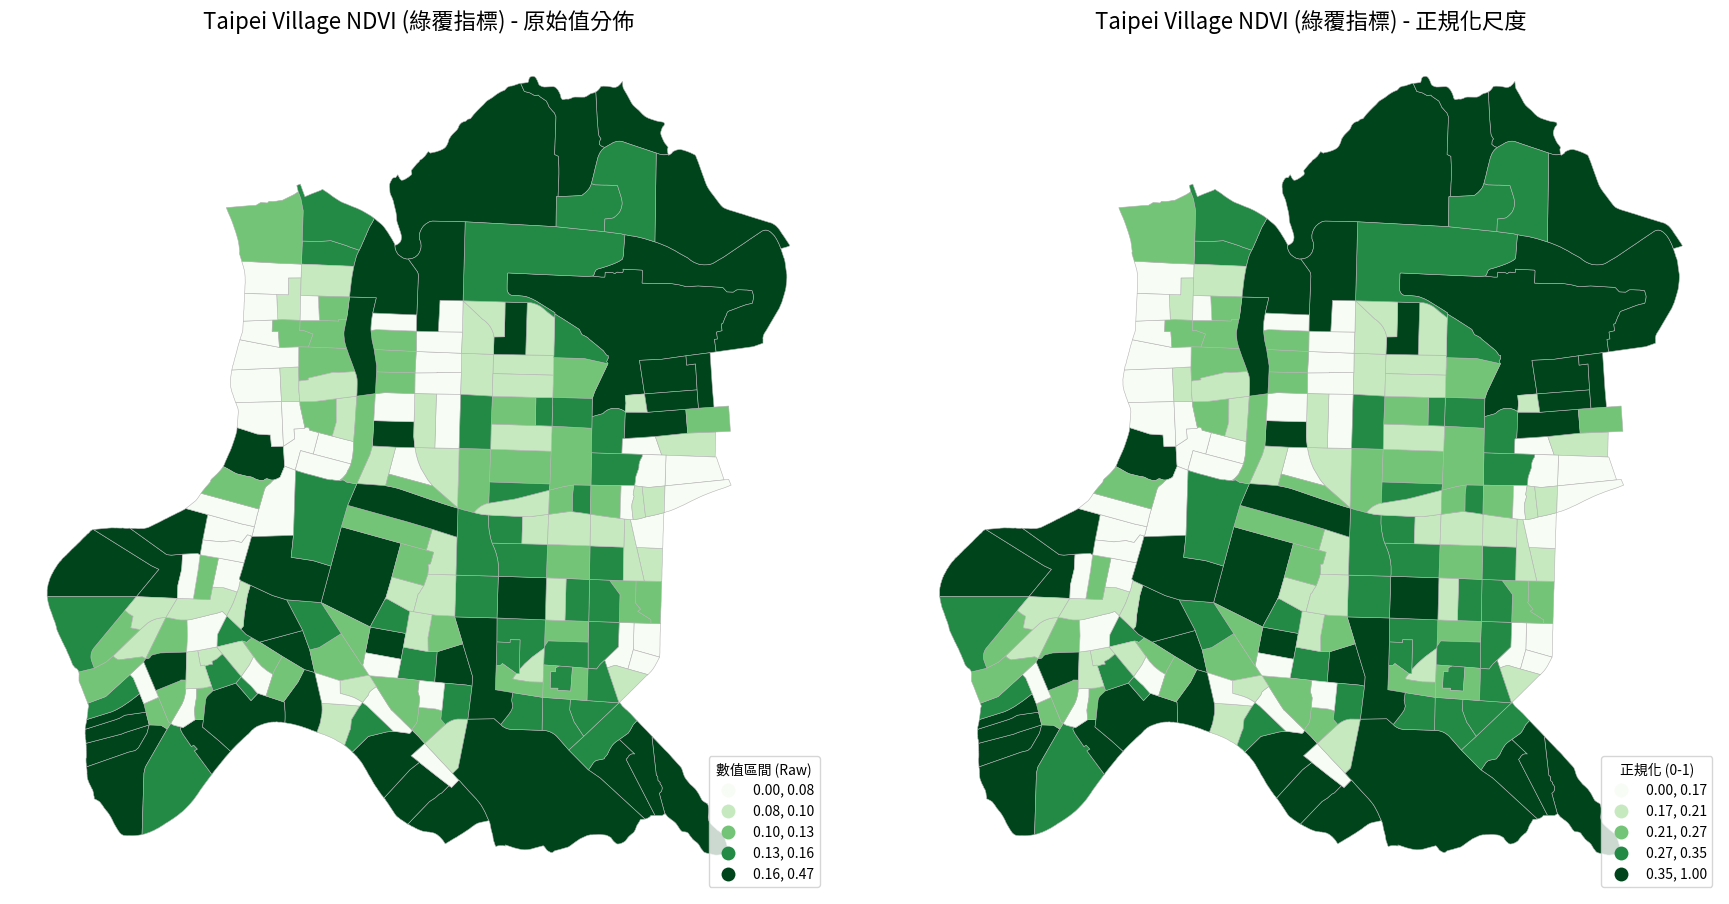


🏢 產製 NDBI (不透水層/建築) 空間分佈圖...


/tmp/ipykernel_4516/2139124836.py:52: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  bounds_gdf.boundary.plot(ax=axes[0], color='#FFD700', linewidth=3.5, zorder=10)
/tmp/ipykernel_4516/2139124836.py:66: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  bounds_gdf.boundary.plot(ax=axes[1], color='#FFD700', linewidth=3.5, zorder=10)


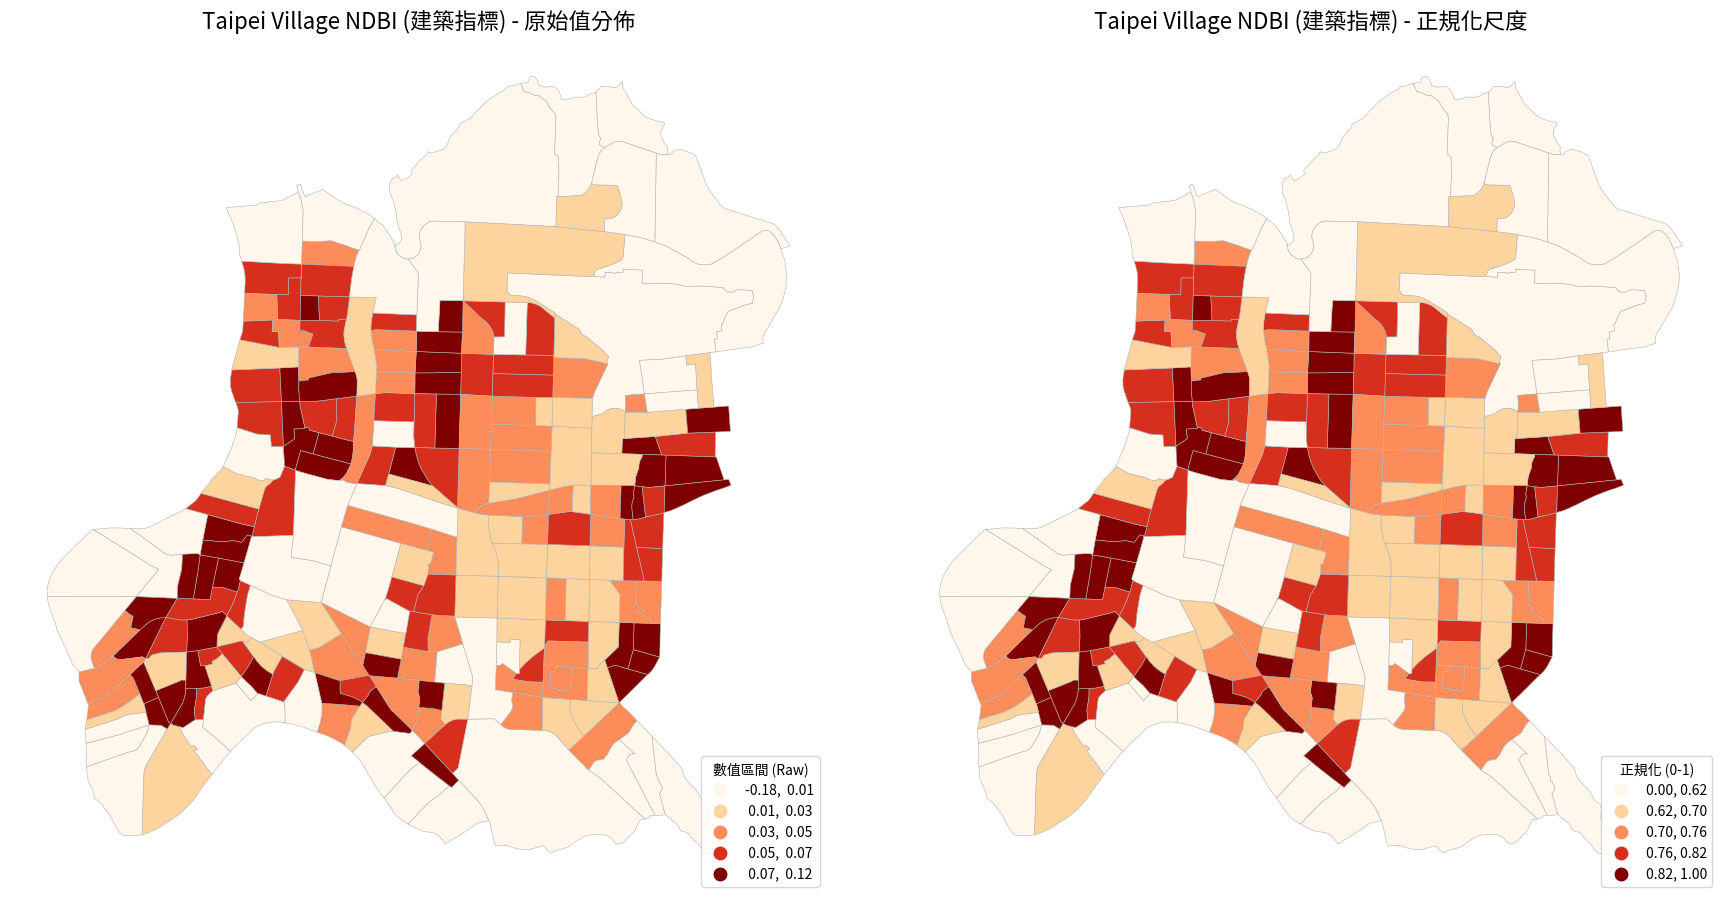

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

print("📊 正在準備資料與設定環境...")

# ==========================================
# 1. 讀取圖資與匯出 CSV 統計表
# ==========================================
gpkg_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.gpkg"
gdf_plot = gpd.read_file(gpkg_path)
gdf_plot = gdf_plot.dropna(subset=['NDVI_mean', 'NDBI_mean'])

# 移除 geometry 轉回 DataFrame 並匯出 CSV
df_stats = pd.DataFrame(gdf_plot.drop(columns=['geometry']))
csv_out_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Village_Vulnerability_Stats.csv"
df_stats.sort_values(by='NDVI_mean', ascending=False).to_csv(csv_out_path, index=False, encoding='utf-8-sig')

# --- 1.2 匯出 GeoJSON 空間圖資 (★新增) ---
print("💾 正在匯出 GeoJSON 檔案...")
geojson_out_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.geojson"

# 存檔前防呆：確保屬性表中沒有 list/dict 欄位導致 GeoJSON 寫入報錯
for col in gdf_plot.columns:
    if gdf_plot[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_plot[col] = gdf_plot[col].astype(str)

gdf_plot.to_file(geojson_out_path, driver="GeoJSON")
print(f"📦 GeoJSON 圖資已儲存至: {geojson_out_path}")

# ==========================================
# 2. 設定中文字型
# ==========================================
font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 3. 準備行政區外框與繪圖函數 (★ 擴充為三圖比較)
# ==========================================
print("🗺️ 正在計算行政區邊界...")
# 確保使用我們統一的 TOWNID 來做精準融合 (若無則退回 TOWNNAME)
dissolve_col = 'TOWNID' if 'TOWNID' in gdf_plot.columns else 'TOWNNAME'
district_bounds = gdf_plot.dissolve(by=dissolve_col)

def plot_maps_hybrid(gdf, bounds_gdf, raw_col, norm_col, title_prefix, cmap):
    # ★ 將畫布改為 1x3，寬度加寬至 24
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # --- 左圖：未正規化 (Raw Data) 保留「變動區間 (Quantiles)」 ---
    gdf.plot(
        column=raw_col, ax=axes[0], scheme='quantiles', k=5,
        cmap=cmap,
        edgecolor='#b3b3b3', linewidth=0.4,
        legend=True, legend_kwds={'loc': 'lower right', 'title': '相對分佈 (Quantiles)'}
    )
    bounds_gdf.plot(ax=axes[0], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
    axes[0].set_title(f"{title_prefix} - 分位數法", fontsize=16, fontweight='bold')
    axes[0].axis('off')

    # --- 中圖：正規化 (Normalized Data) 改用「固定等距區間」 ---
    unified_bins = [0.2, 0.4, 0.6, 0.8, 1.0]
    gdf.plot(
        column=norm_col, ax=axes[1],
        scheme='UserDefined', classification_kwds={'bins': unified_bins},
        cmap=cmap,
        edgecolor='#b3b3b3', linewidth=0.4,
        legend=True, legend_kwds={'loc': 'lower right', 'title': '絕對區間 (0.2 一距)'}
    )
    bounds_gdf.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
    axes[1].set_title(f"{title_prefix} - 正規化尺度", fontsize=16, fontweight='bold')
    axes[1].axis('off')

    # --- 右圖：未正規化 (Raw Data) 新增「自然間斷法 (Natural Breaks)」 ---
    # ★ 關鍵修改：使用 scheme='NaturalBreaks'
    gdf.plot(
        column=raw_col, ax=axes[2], scheme='NaturalBreaks', k=5,
        cmap=cmap,
        edgecolor='#b3b3b3', linewidth=0.4,
        legend=True, legend_kwds={'loc': 'lower right', 'title': '自然間斷 (Natural Breaks)'}
    )
    bounds_gdf.plot(ax=axes[2], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
    axes[2].set_title(f"{title_prefix} - 自然間斷法", fontsize=16, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. 產出成果比較圖
# ==========================================
print("🌳 產製 NDVI (植被覆蓋) 空間分佈圖...")
plot_maps_hybrid(gdf_plot, district_bounds, 'NDVI_mean', 'NDVI_norm', 'Taipei Village NDVI', 'Greens')

print("\n🏢 產製 NDBI (不透水層/建築) 空間分佈圖...")
plot_maps_hybrid(gdf_plot, district_bounds, 'NDBI_mean', 'NDBI_norm', 'Taipei Village NDBI', 'OrRd')

### 第七步：獲取 Landsat 地表溫度 (LST) 並重採樣

1. **資料源**：改用微軟 STAC 的 `landsat-c2-l2` (Landsat 8/9 Collection 2 Level-2)。
2. **波段選擇**：`lwir11` (Band 10，表面溫度)。
3. **單位轉換**：Landsat 儲存的是整數 DN 值，必須乘上縮放係數 (`0.00341802`) 並加上位移 (`149.0`) 轉為凱氏溫度 (Kelvin)，最後減去 `273.15` 轉為攝氏溫度 (°C)。
4. **重採樣 (Resampling)**：使用 `Bilinear` 演算法，將 30m 的 LST 對齊到我們先前儲存的 10m NDVI 網格上。

🔍 正在連線尋找 Landsat 夏季無雲影像...
✅ 找到 4 張符合條件的影像。準備預覽前 3 名...

處理 Rank 1 (2025-08-23)...

處理 Rank 2 (2025-06-28)...

處理 Rank 3 (2025-08-15)...


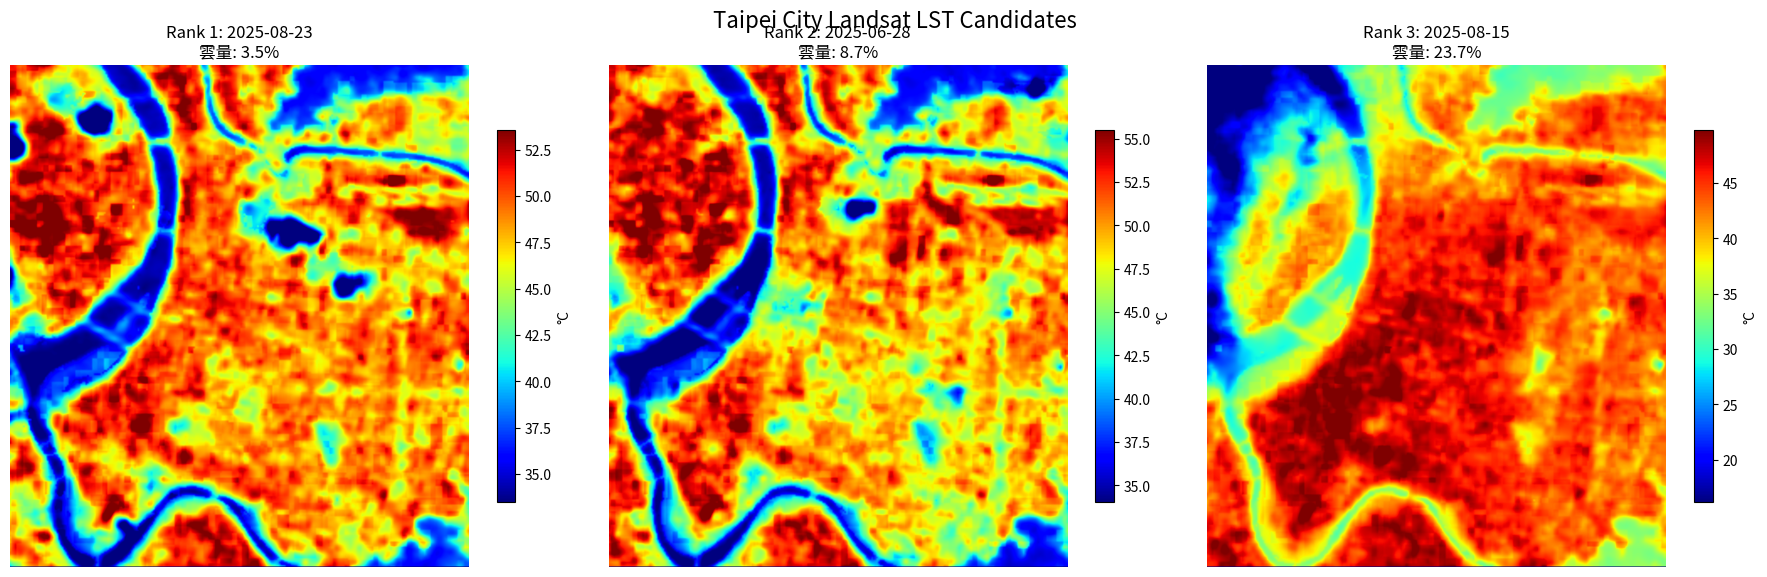


👀 請觀察上方的圖表。
好的 LST 影像應該能清晰看出都市輪廓 (如淡水河較涼、萬華中正區較熱)。
如果某張圖有一大片極低溫(藍色)的圓形或不規則形狀，那通常是剛好有雲飄在台北上空。


In [ ]:
import os
import pystac_client
import planetary_computer as pc
import rioxarray as rxr
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt

print("🔍 正在連線尋找 Landsat 夏季無雲影像...")

# 搜尋 Landsat 影像
search = catalog.search(
    collections=[COLLECTION_LST],
    bbox=TAIPEI_BBOX,
    datetime=f"{EVENT_START}/{EVENT_END}",
    query={"eo:cloud_cover": {"lt": 40}} # 放寬到 40% 以獲得更多選擇
)
items_landsat = list(search.items())

if len(items_landsat) == 0:
    raise ValueError("❌ 找不到符合條件的 Landsat 影像，請嘗試調高雲量限制或擴大日期。")

# 依雲量排序
items_landsat.sort(key=lambda i: i.properties["eo:cloud_cover"])

print(f"✅ 找到 {len(items_landsat)} 張符合條件的影像。準備預覽前 3 名...")

# 讀取先前的 NDVI 作為重採樣基準
ndvi_ref_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_NDVI_2025_10m.tif"
ref_raster = rxr.open_rasterio(ndvi_ref_path)

# 準備預覽圖面 (1 row, 3 columns)
n_preview = min(len(items_landsat), 3)
fig, axes = plt.subplots(1, n_preview, figsize=(6 * n_preview, 6))
if n_preview == 1: axes = [axes] # 確保 axes 可迭代

# 存放處理好的 LST 影像以便後續儲存
processed_lst = {}

for i in range(n_preview):
    item = items_landsat[i]
    cloud_pct = item.properties.get("eo:cloud_cover", 0)
    obs_date = item.datetime.strftime("%Y-%m-%d")

    print(f"\n處理 Rank {i+1} ({obs_date})...")

    try:
        # 讀取並裁切
        lst_href = item.assets["lwir11"].href
        lst_raw = rxr.open_rasterio(lst_href).rio.clip_box(*TAIPEI_BBOX, crs="EPSG:4326")

        # 轉換為攝氏溫度
        lst_raw = lst_raw.where(lst_raw > 0)
        lst_celsius = (lst_raw * 0.00341802) + 149.0 - 273.15

        # 重採樣對齊 10m
        lst_resampled = lst_celsius.rio.reproject_match(ref_raster, resampling=Resampling.bilinear)
        processed_lst[i] = {"item": item, "data": lst_resampled}

        # 取得這張影像的實際最高與最低溫 (排除 NaN 與極端異常值)
        # 這裡我們取 2% 和 98% 分位數來拉伸對比，去除雲層(過低)或雜訊(過高)的影響
        data_valid = lst_resampled.squeeze().values
        data_valid = data_valid[~np.isnan(data_valid)]

        if len(data_valid) > 0:
            v_min = np.percentile(data_valid, 2)
            v_max = np.percentile(data_valid, 98)
        else:
            v_min, v_max = 20, 40 # 預設安全值

        # 繪圖
        im = axes[i].imshow(lst_resampled.squeeze(), cmap='jet', vmin=v_min, vmax=v_max)
        axes[i].set_title(f"Rank {i+1}: {obs_date}\n雲量: {cloud_pct:.1f}%", fontsize=12)
        axes[i].axis('off')
        fig.colorbar(im, ax=axes[i], shrink=0.7, label='°C')

    except Exception as e:
        print(f"⚠️ 處理 {obs_date} 時發生錯誤: {e}")
        axes[i].set_title(f"Rank {i+1}: 錯誤")
        axes[i].axis('off')

plt.suptitle(f"Taipei City Landsat LST Candidates", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 讓使用者選擇要保留哪一張 ---
print("\n👀 請觀察上方的圖表。")
print("好的 LST 影像應該能清晰看出都市輪廓 (如淡水河較涼、萬華中正區較熱)。")
print("如果某張圖有一大片極低溫(藍色)的圓形或不規則形狀，那通常是剛好有雲飄在台北上空。")

In [ ]:
# 這裡先預設儲存第一張，但如果你想換，改這裡的數字！
SELECTED_RANK = 1  # 換成 2 或 3 來儲存另一張

if (SELECTED_RANK - 1) in processed_lst:
    final_data = processed_lst[SELECTED_RANK - 1]["data"]
    final_item = processed_lst[SELECTED_RANK - 1]["item"]

    lst_out_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_LST_2025_10m.tif"
    final_data.squeeze().rio.to_raster(lst_out_path)
    print(f"\n✅ 已選擇 Rank {SELECTED_RANK} ({final_item.datetime.strftime('%Y-%m-%d')}) 並儲存至: {lst_out_path}")
else:
    print(f"❌ 錯誤：無法儲存 Rank {SELECTED_RANK}。")

### 第七步：LST 區域統計 (Zonal Statistics) 與指標整併

此區塊將執行以下任務：
1. **區域統計**：計算每個村里多邊形內 LST 的平均攝氏溫度。
2. **正規化處理**：執行 Min-Max 正規化 ($0 \sim 1$)，將溫度轉化為無量綱的熱壓力指標。
3. **資料庫更新**：將 LST 指標寫入原本的 `Taipei_Vulnerability_Villages.gpkg` 與統計 CSV。
4. **視覺化呈現**：產出原始溫度與正規化溫度的分級對照圖，並以金黃色高亮顯示六大行政區界。

🗺️ 正在載入村里圖資...
🌡️ 正在計算各村里平均地表溫度 (LST)...
💾 正在更新資料庫檔案...
✅ LST 數據整併完成！
   - GPKG 更新路徑: /content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.gpkg
   - CSV 更新路徑: /content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Village_Vulnerability_Stats.csv
🎨 正在產製視覺化圖表...


/tmp/ipykernel_15551/704563583.py:75: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  district_bounds.plot(ax=axes[0], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
/tmp/ipykernel_15551/704563583.py:90: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)


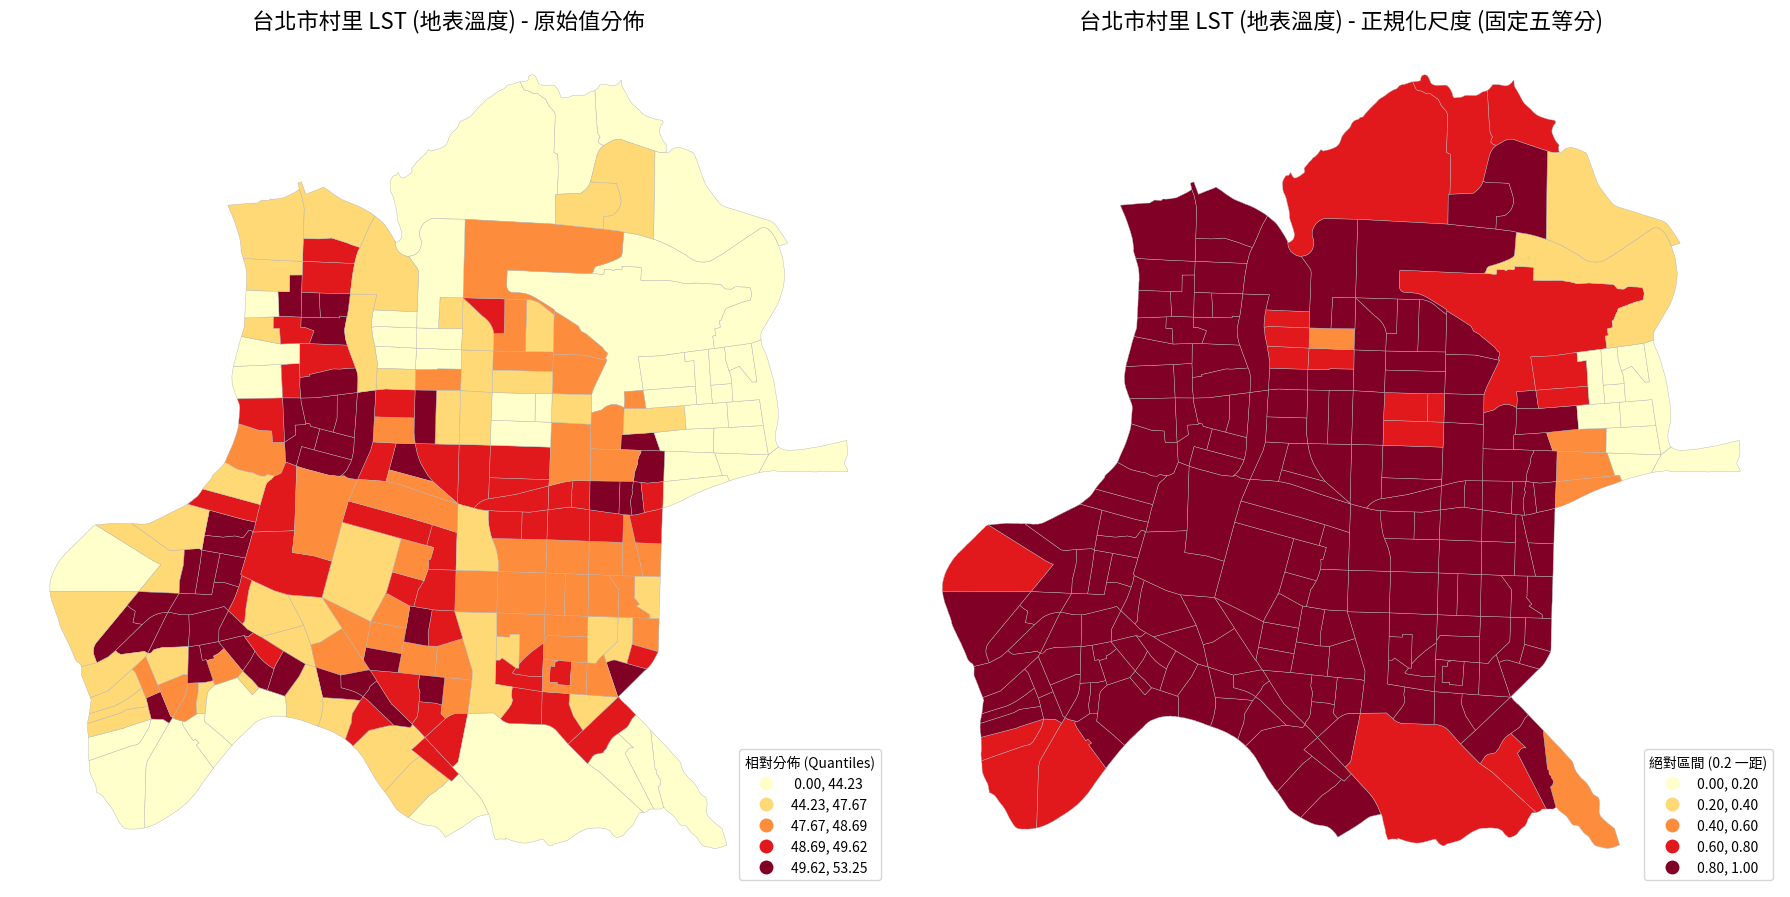

In [ ]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ==========================================
# 1. 路徑設定
# ==========================================
gpkg_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.gpkg"
lst_tif_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_LST_2025_10m.tif"
csv_out_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Village_Vulnerability_Stats.csv" # 修正了路徑少一個斜線的問題

# 讀取現有的 GPKG
print("🗺️ 正在載入村里圖資...")
gdf_final = gpd.read_file(gpkg_path)

# ==========================================
# 2. 執行 LST 區域統計
# ==========================================
print("🌡️ 正在計算各村里平均地表溫度 (LST)...")
lst_stats = zonal_stats(gdf_final, lst_tif_path, stats="mean", nodata=np.nan)
gdf_final['LST_mean'] = [s['mean'] if s['mean'] is not None else np.nan for s in lst_stats]

# 正規化處理 (0-1)
def min_max_normalize(series):
    return (series - series.min()) / (series.max() - series.min())

gdf_final['LST_norm'] = min_max_normalize(gdf_final['LST_mean'])

# ==========================================
# 3. 更新存檔 (GPKG 與 CSV)
# ==========================================
print("💾 正在更新資料庫檔案...")
# 清理欄位格式
for col in gdf_final.columns:
    if len(gdf_final) > 0 and isinstance(gdf_final[col].iloc[0], (dict, list)):
        gdf_final = gdf_final.drop(columns=[col])

gdf_final.to_file(gpkg_path, driver="GPKG")

# 匯出 CSV 統計表
df_stats = pd.DataFrame(gdf_final.drop(columns=['geometry']))
df_stats.sort_values(by='LST_mean', ascending=False).to_csv(csv_out_path, index=False, encoding='utf-8-sig')

# --- 匯出 GeoJSON 空間圖資 ---
print("💾 正在匯出 GeoJSON 檔案...")
geojson_out_path = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.geojson"

# 存檔前防呆：確保屬性表中沒有 list/dict 欄位導致 GeoJSON 寫入報錯
for col in gdf_final.columns:
    if gdf_final[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_final[col] = gdf_final[col].astype(str)

gdf_final.to_file(geojson_out_path, driver="GeoJSON")
print(f"📦 GeoJSON 圖資已擴充更新至: {geojson_out_path}")

print(f"✅ LST 數據整併完成！")
print(f"   - GPKG 更新路徑: {gpkg_path}")
print(f"   - CSV 更新路徑: {csv_out_path}")

# ==========================================
# 4. 繪製 LST 分級圖 (★ 擴充為三張圖：分位數、固定區間、自然間斷法)
# ==========================================
# 設定字體
font_path = '/tmp/NotoSansTC.otf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Noto Sans CJK TC'
    plt.rcParams['axes.unicode_minus'] = False

# 計算行政區融合邊界
dissolve_col = 'TOWNID' if 'TOWNID' in gdf_final.columns else 'TOWNNAME'
district_bounds = gdf_final.dissolve(by=dissolve_col)

print("🎨 正在產製視覺化圖表...")
# ★ 關鍵修改：將畫布改為 1x3，並將寬度加寬至 24，避免圖表擁擠
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# --- 左圖：LST 原始攝氏溫度 (保留分位數 Quantiles) ---
gdf_final.plot(
    column='LST_mean', ax=axes[0], scheme='quantiles', k=5, cmap='YlOrRd',
    edgecolor='#b3b3b3', linewidth=0.3, legend=True,
    legend_kwds={'loc': 'lower right', 'title': '相對分佈 (Quantiles)'}
)
district_bounds.plot(ax=axes[0], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
axes[0].set_title("台北市村里 LST - 分位數法 (Quantiles)", fontsize=16, fontweight='bold')
axes[0].axis('off')

# --- 中圖：LST 正規化值 (改為固定五等分 UserDefined) ---
unified_bins = [0.2, 0.4, 0.6, 0.8, 1.0]
gdf_final.plot(
    column='LST_norm', ax=axes[1],
    scheme='UserDefined', classification_kwds={'bins': unified_bins},
    cmap='YlOrRd',
    edgecolor='#b3b3b3', linewidth=0.3, legend=True,
    legend_kwds={'loc': 'lower right', 'title': '絕對區間 (0.2 一距)'}
)
district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
axes[1].set_title("台北市村里 LST - 正規化固定五等分", fontsize=16, fontweight='bold')
axes[1].axis('off')

# --- 右圖：LST 原始攝氏溫度 (新增：自然間斷法 Natural Breaks) ---
# ★ 關鍵修改：使用 scheme='NaturalBreaks'
gdf_final.plot(
    column='LST_mean', ax=axes[2], scheme='NaturalBreaks', k=5, cmap='YlOrRd',
    edgecolor='#b3b3b3', linewidth=0.3, legend=True,
    legend_kwds={'loc': 'lower right', 'title': '自然間斷 (Natural Breaks)'}
)
district_bounds.plot(ax=axes[2], facecolor='none', edgecolor='#FFD700', linewidth=3.5, zorder=10)
axes[2].set_title("台北市村里 LST - 自然間斷法 (Natural Breaks)", fontsize=16, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()